In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### VADER at Utterance Level

In [ ]:
df_M_utt = pd.read_csv("M/data_sentiment/Doom_utt_final_filt.csv")
df_T_utt = pd.read_csv("T/Data/destiny2_utt_final_filt.csv")
df_E_utt = pd.read_csv("E_10+/Data/PvZGardenWarfare_utt_final_filt.csv")

df_M_utt = pd.concat([df_M_utt, pd.read_csv("M/data_sentiment/blackops3_utt_final.csv")], axis=0, ignore_index=True)
df_T_utt = pd.concat([df_T_utt, pd.read_csv("T/Data/StarWarsBattlefront_utt_final.csv")], axis=0, ignore_index=True)
df_E_utt = pd.concat([df_E_utt, pd.read_csv("E_10+/Data/splatoon_utt_final.csv")], axis=0, ignore_index=True)

list_of_corpora = [df_M_utt, df_T_utt, df_E_utt]


In [ ]:
for df in list_of_corpora:
    df = df.rename(columns={"sentiment_label": "VADER_sentiment_label"})

    df = df.rename(columns={"compound": "VADER_Compound"})


In [15]:
vader_map = {
    "positive": "Positive",
    "negative": "Negative",
    "neutral": "Neutral"
}

label_map = {
    -1: "Negative",
    0: "Neutral",
    1: "Positive"
}

for df in list_of_corpora:
    df["VADER_sentiment_label"] = df["VADER_sentiment_label"].map(vader_map)

    df["bert_label"] = df["bert_numeric"].map(label_map)

## Utt - Summary Stats - VADER

In [ ]:
print("\n=== Dataset Overview ===")
print("\nShape:", df_M_utt.shape)

print("\n=== Sentiment Label Distribution ===")
vader_counts_M = df_M_utt["VADER_sentiment_label"].value_counts()
vader_percent_M = df_M_utt["VADER_sentiment_label"].value_counts(normalize=True) * 100

print("\nRaw VADER Counts: \n", vader_counts_M)
print("\nPercentage:\n", vader_percent_M)

compound = df_M_utt["compound"]

print("\n=== Compound Score Statistics ===")
print(df_M_utt["compound"].describe())



=== Dataset Overview ===

Shape: (282896, 16)

=== Sentiment Label Distribution ===

Raw VADER Counts: 
 VADER_sentiment_label
Positive    132410
Negative     98991
Neutral      51495
Name: count, dtype: int64

Percentage:
 VADER_sentiment_label
Positive    46.805186
Negative    34.992011
Neutral     18.202802
Name: proportion, dtype: float64

=== Compound Score Statistics ===
count    282896.000000
mean          0.071960
std           0.534514
min          -1.000000
25%          -0.340000
50%           0.000000
75%           0.511600
max           0.999900
Name: compound, dtype: float64


In [ ]:
print("\n=== Dataset Overview ===")
print("\nShape:", df_T_utt.shape)

print("\n=== Sentiment Label Distribution ===")
vader_counts_T = df_T_utt["VADER_sentiment_label"].value_counts()
vader_percent_T = df_T_utt["VADER_sentiment_label"].value_counts(normalize=True) * 100

print("\nRaw VADER Counts: \n", vader_counts_T)
print("\nPercentage:\n", vader_percent_T)

compound = df_T_utt["compound"]

print("\n=== Compound Score Statistics ===")
print(df_T_utt["compound"].describe())


=== Dataset Overview ===

Shape: (285418, 16)

=== Sentiment Label Distribution ===

Raw VADER Counts: 
 VADER_sentiment_label
Positive    143751
Negative     86287
Neutral      55380
Name: count, dtype: int64

Percentage:
 VADER_sentiment_label
Positive    50.365079
Negative    30.231800
Neutral     19.403121
Name: proportion, dtype: float64

=== Compound Score Statistics ===
count    285418.000000
mean          0.131713
std           0.517133
min          -0.999700
25%          -0.234000
50%           0.057150
75%           0.571900
max           0.999900
Name: compound, dtype: float64


In [ ]:
print("\n=== Dataset Overview ===")
print("\nShape:", df_E_utt.shape)

print("\n=== Sentiment Label Distribution ===")
vader_counts_E = df_E_utt["VADER_sentiment_label"].value_counts()
vader_percent_E = df_E_utt["VADER_sentiment_label"].value_counts(normalize=True) * 100

print("\nRaw VADER Counts: \n", vader_counts_E)
print("\nPercentage:\n", vader_percent_E)

compound = df_E_utt["compound"]

print("\n=== Compound Score Statistics ===")
print(df_E_utt["compound"].describe())


=== Dataset Overview ===

Shape: (272066, 16)

=== Sentiment Label Distribution ===

Raw VADER Counts: 
 VADER_sentiment_label
Positive    138776
Negative     76556
Neutral      56734
Name: count, dtype: int64

Percentage:
 VADER_sentiment_label
Positive    51.008211
Negative    28.138760
Neutral     20.853028
Name: proportion, dtype: float64

=== Compound Score Statistics ===
count    272066.000000
mean          0.149940
std           0.511909
min          -0.999900
25%          -0.165500
50%           0.077200
75%           0.592700
max           0.999800
Name: compound, dtype: float64


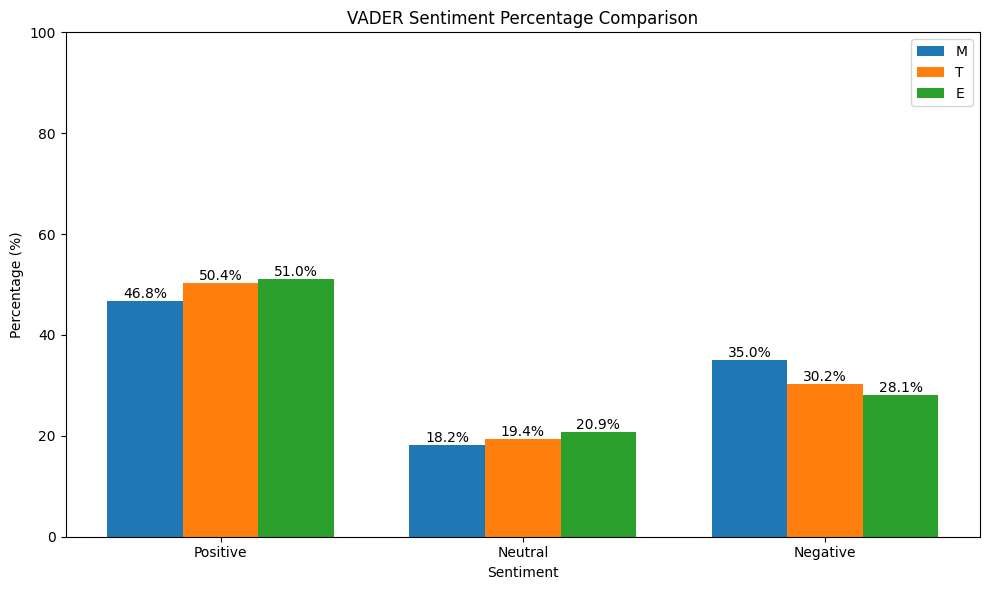

In [ ]:
labels = ['Positive', 'Neutral', 'Negative']
x = np.arange(len(labels))
width = 0.25

percent1 = vader_percent_M.reindex(labels)
percent2 = vader_percent_T.reindex(labels)
percent3 = vader_percent_E.reindex(labels)

plt.figure(figsize=(10, 6))

bars1 = plt.bar(x - width, percent1.values, width, label="M")
bars2 = plt.bar(x, percent2.values, width, label="T")
bars3 = plt.bar(x + width, percent3.values, width, label="E")

for i in range(len(labels)):
    plt.text(x[i] - width, percent1.values[i], f"{percent1.values[i]:.1f}%", ha='center', va='bottom')
    plt.text(x[i], percent2.values[i], f"{percent2.values[i]:.1f}%", ha='center', va='bottom')
    plt.text(x[i] + width, percent3.values[i], f"{percent3.values[i]:.1f}%", ha='center', va='bottom')

plt.xticks(x, labels)

plt.title(f"VADER Sentiment Percentage Comparison")
plt.xlabel("Sentiment")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ANOVA
from scipy import stats

f_stat, p_value = stats.f_oneway(df_E_utt["compound"], df_T_utt["compound"], df_M_utt["compound"])

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 1711.7938817154309
p-value: 0.0


In [ ]:
# Kruskals
h_stat, p_value = stats.kruskal(df_E_utt["compound"], df_T_utt["compound"], df_M_utt["compound"])

print("H-statistic:", h_stat)
print("p-value:", p_value)

H-statistic: 3045.614318408092
p-value: 0.0
